In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [120]:
class AttritionModel:
    
    def __init__(self, beta=1):
        self.beta = beta  # for F-beta score
        self.pipeline = None
        self.best_threshold = None
        
    # -------------------------
    # Build Pipeline
    # -------------------------
    def build_pipeline(self):
        self.pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                solver='liblinear',
                max_iter=2000,
                random_state=42
            ))
        ])
    
    
    # -------------------------
    # Hyperparameter Tuning
    # -------------------------
    def tune_model(self, X, y):
        param_grid = {
            'model__C': [0.01, 0.1, 0.5, 1, 5]
        }
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        grid = GridSearchCV(
            self.pipeline,
            param_grid,
            cv=skf,
            scoring='f1',
            n_jobs=-1
        )
        
        grid.fit(X, y)
        self.pipeline = grid.best_estimator_
        
        print(f"Best C: {grid.best_params_['model__C']}")
    
    
    # -------------------------
    # Threshold Optimization
    # -------------------------
    def find_best_threshold(self, X, y):
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        y_proba = cross_val_predict(
            self.pipeline,
            X,
            y,
            cv=skf,
            method='predict_proba'
        )[:, 1]
        
        precision, recall, thresholds = precision_recall_curve(y, y_proba)
        
        # beta = self.beta
        
        # f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)
        
        # best_idx = np.argmax(f_beta)
        # self.best_threshold = thresholds[best_idx]

        target_recall = 0.75

        valid = np.where(recall >= target_recall)[0]
        best_idx = valid[np.argmax(precision[valid])]
        # self.best_threshold = thresholds[best_idx]
        self.best_threshold = 0.61
        
        print(f"Best Threshold: {self.best_threshold:.4f}")
        # print(f"Best F{beta} Score: {f_beta[best_idx]:.4f}")
        
        return precision, recall, best_idx
    
    
    # -------------------------
    # Fit Final Model
    # -------------------------
    def fit(self, X, y):
        self.pipeline.fit(X, y)
    
    
    # -------------------------
    # Predict with threshold
    # -------------------------
    def predict(self, X):
        probs = self.pipeline.predict_proba(X)[:, 1]
        return (probs >= self.best_threshold).astype(int)
    
    
    # -------------------------
    # Evaluate
    # -------------------------
    def evaluate(self, X, y):
        y_pred = self.predict(X)
        y_proba = self.pipeline.predict_proba(X)[:, 1]
        
        print("\n── Evaluation ──")
        print(classification_report(y, y_pred))
        print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")
        
        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot()
        plt.title("Confusion Matrix")
        plt.show()
    
    
    # -------------------------
    # Plot PR Curve
    # -------------------------
    def plot_pr_curve(self, precision, recall, best_idx):
        plt.figure(figsize=(7,5))
        plt.plot(recall, precision)
        plt.scatter(recall[best_idx], precision[best_idx])
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.show()
    
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)[:, 1]



In [121]:
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')

In [122]:
# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

In [123]:
# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [124]:
# Initialize Model
model = AttritionModel(beta=1)  # beta=1 → F1, beta=2 → recall focus

model.build_pipeline()

In [125]:
# Tune C
model.tune_model(X_train, y_train)

/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Best C: 0.5


/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Best Threshold: 0.6100


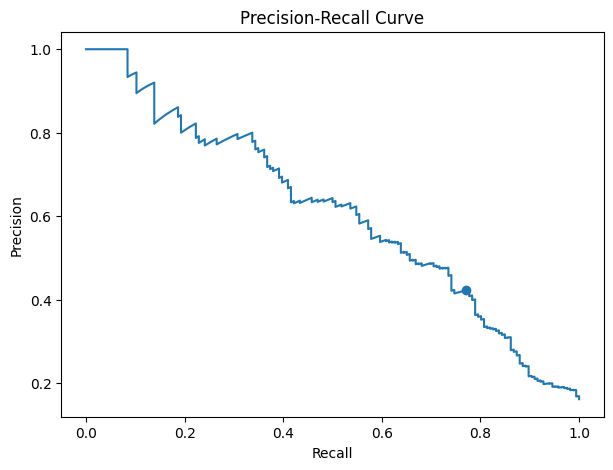

In [126]:
# Find best threshold (OOF)
precision, recall, best_idx = model.find_best_threshold(X_train, y_train)
model.plot_pr_curve(precision, recall, best_idx)

In [127]:
# Fit final model
model.fit(X_train, y_train)


── Evaluation ──
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       370
           1       0.51      0.68      0.58        71

    accuracy                           0.84       441
   macro avg       0.72      0.77      0.74       441
weighted avg       0.86      0.84      0.85       441

ROC-AUC: 0.8322


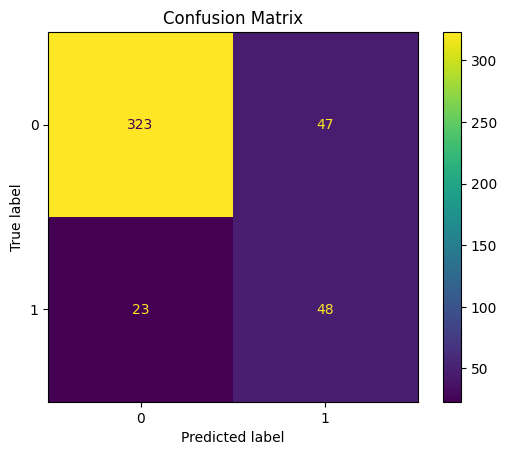

In [128]:
# Evaluate
model.evaluate(X_test, y_test)

In [129]:
y_test_proba = model.predict_proba(X_test)
# Try threshold from 0.6 to 0.615 with interval of 0.005
for t in np.arange(0.6, 0.620, 0.0025):
    y_pred = (y_test_proba >= t).astype(int)
    
    print(f"\nThreshold = {t:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")



Threshold = 0.600
[[322  48]
 [ 23  48]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       370
           1       0.50      0.68      0.57        71

    accuracy                           0.84       441
   macro avg       0.72      0.77      0.74       441
weighted avg       0.86      0.84      0.85       441

ROC-AUC: 0.7732

Threshold = 0.602
[[323  47]
 [ 23  48]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       370
           1       0.51      0.68      0.58        71

    accuracy                           0.84       441
   macro avg       0.72      0.77      0.74       441
weighted avg       0.86      0.84      0.85       441

ROC-AUC: 0.7745

Threshold = 0.605
[[323  47]
 [ 23  48]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       370
           1       0.51      0.68      0.58        71

    accuracy            

In [130]:
import shap

# Extract trained model
scaler = model.pipeline.named_steps['scaler']
lr_model = model.pipeline.named_steps['model']

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
# Create explainer
explainer = shap.Explainer(lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

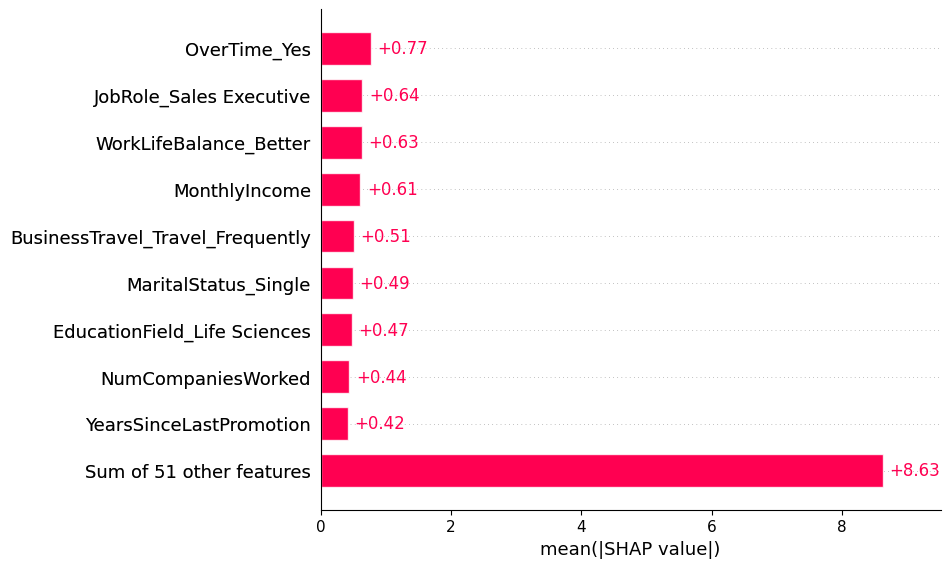

In [131]:
shap.plots.bar(shap_values)

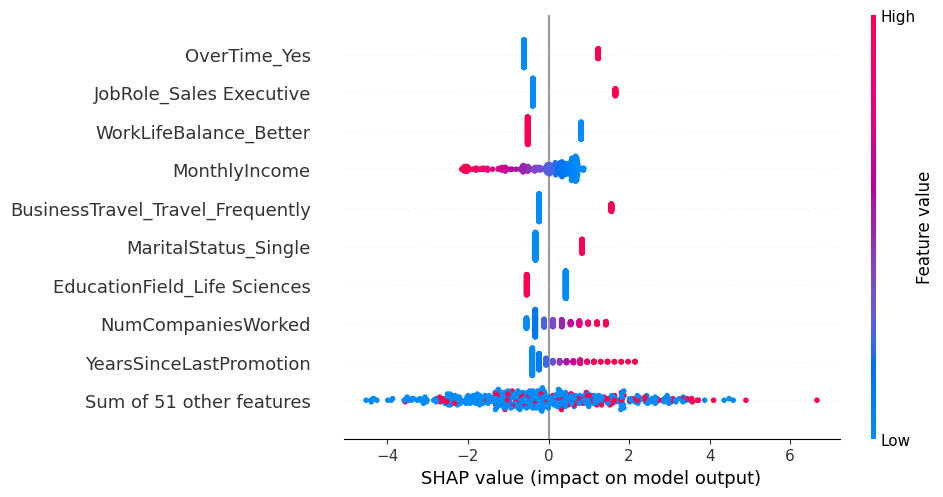

In [132]:
shap.plots.beeswarm(shap_values)

Prediction: [0]


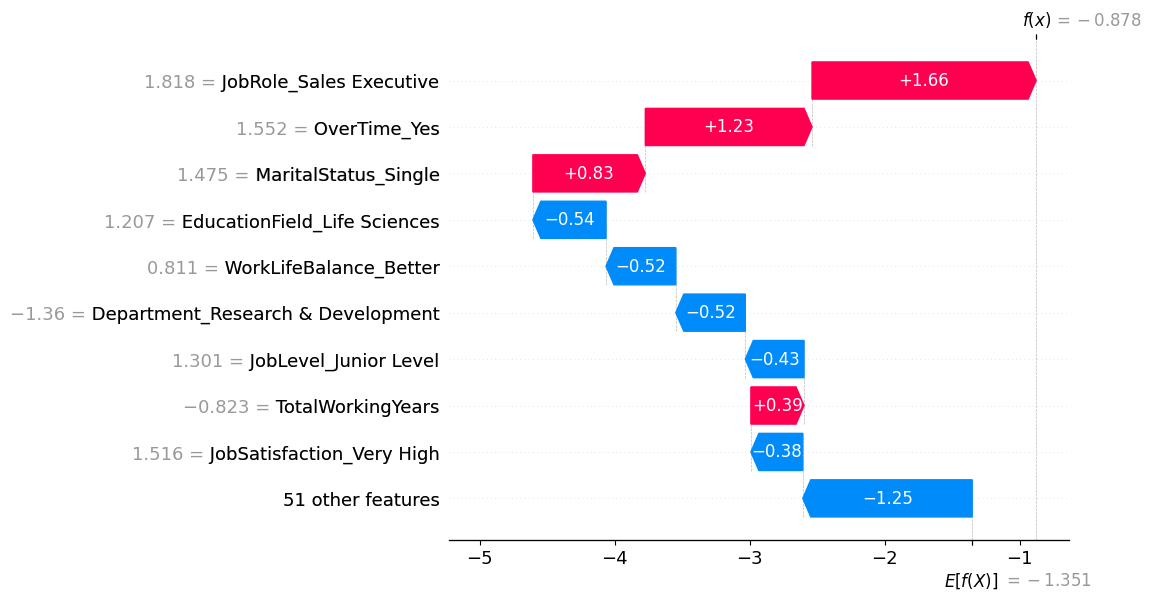

In [133]:
idx = 0  # choose employee

print("Prediction:", model.predict(X_test.iloc[[idx]]))

shap.plots.waterfall(shap_values[idx])